# 00 · Overview and quick start

**VisionServe** is a small program that looks at photos for you. You send it a photo, and it
answers with what is in the photo: boxes around objects, outlines of objects, depth, faces,
text, and more. In this notebook you will make your first request and learn to read the answer.

**What you will learn**

- what VisionServe is, in plain words
- how to check that the server is running and which models it has
- how to download a model
- how to send a photo and read the answer (the JSON)
- how to draw the answer on the photo
- how to do the same request with `curl`, without Python

**Time needed:** about 20 minutes.

**What you need before you start**

- Python with the packages in `requirements.txt` (see the [README](README.md), step 1)
- a running VisionServe server (see the [README](README.md), step 2)
- no knowledge of computer vision: every new word is explained

**Steps**

1. What VisionServe is
2. Check the setup
3. Download a model
4. Send your first photo
5. Read the answer
6. Draw the answer
7. The same request with `curl`
8. Large photos: client resize

## The series

This is the first of nine notebooks. Do 00, 01 and 02 first. After that, pick the ones you need.

| # | Notebook | What you learn | Time |
|---|---|---|---|
| 00 | [Overview and quick start](00-overview-and-quickstart.ipynb) | What VisionServe is; check the server; download a model; first request; read and draw the JSON; the same with `curl` | 20 min |
| 01 | [Tour of tasks](01-tour-of-tasks.ipynb) | One example per task: detection, open-vocabulary detection, segmentation, Grounded-SAM, depth, faces, text (OCR), classification, CLIP | 40 min |
| 02 | [Parameters](02-parameters.ipynb) | What the common options change, with before/after pictures: thresholds, prompt words, size filters, `roi`, `dilate`, point labels, client resize; a slider | 40 min |
| 03 | [What a model takes and gives back](03-inspect-a-model.ipynb) | `visionserve inspect`: the model card, input shapes, the picture the model really gets, a broken manifest | 25 min |
| 04 | [Your own checkpoint](04-your-own-checkpoint.ipynb) | Serve a model you trained: `visionserve convert` and `import`, the convert report, class names, licences | 20 min + 2–4 min of commands |
| 05 | [Check against training](05-check-against-training.ipynb) | `visionserve check`: does the server prepare photos like your training code? PASS/FAIL, the HTML report, accuracy on labels | 30 min |
| 06 | [Speed and client resize](06-speed-and-client-resize.ipynb) | `visionserve bench`: latency, throughput, p50/p95, CPU vs GPU; what client resize saves | 20 min |
| 07 | [Smaller and faster for a Jetson](07-jetson-sensitivity-and-optimize.ipynb) | `visionserve sensitivity` and `optimize`: FP16 / INT8 / mixed versions, size, accuracy and speed | 30 min + 8–20 min of commands (GPU, depends on load) |
| 08 | [Robotics: depth, grasps, background](08-robotics.ipynb) | Relative depth and the nearest object, grasps for a two-finger gripper, the support surface, and the limits | 40 min |

## 1. What VisionServe is

A **model** is a file with a trained neural network: a big math function that learned from many
example photos. It takes a photo and gives numbers back. VisionServe **runs** models (this is
called *inference*); it does not train them.

VisionServe is a **server**: a program that runs all the time and waits for requests. Your code
(Python, `curl`, a web page) is the **client**. The client sends a photo over **HTTP** (the language
of the web). It gets an answer in **JSON** (text with names and values, easy for programs to
read).

```
  your code (client)                VisionServe server                    the answer
  ------------------                ------------------                    ----------
  Python / curl / web   -- photo -->  prepares the photo,     -- JSON -->  boxes, masks,
                                      runs the model on                    depth, text...
                                      your CPU or GPU
```

Everything runs on your own computer. Nothing is sent to the internet.

![Grounded-SAM: the words "dog. person. bench." in, boxes and outlines out](../website/docs/assets/img/grounded-sam-372819.jpg)

*Example answer: you type "dog. person. bench." and VisionServe draws a box and an outline
around each one.*

The code below loads the helper functions for this series (from the file `handson.py` in this
folder) and shows four of the photos we use. The photos are in the `images/` folder.

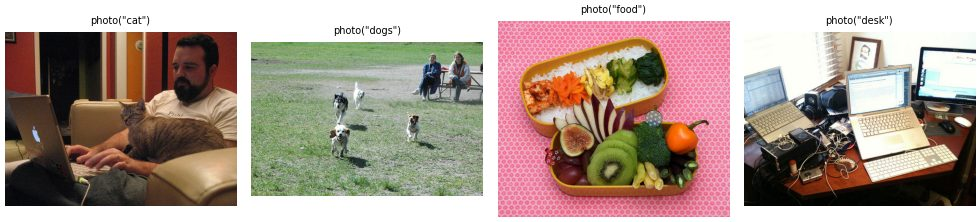

In [1]:
from handson import connect, ensure_model, photo, show, show_side_by_side, print_json, table

show_side_by_side([photo("cat"), photo("dogs"), photo("food"), photo("desk")],
                  titles=['photo("cat")', 'photo("dogs")', 'photo("food")', 'photo("desk")'])

**What you see**

Four photos in one row. `photo("cat")` gives the path of a photo file, for example
`images/cat.jpg`. All photos come from the COCO dataset (a large public collection of photos);
they are 640 pixels wide.

<details><summary><b>In detail</b></summary>

- The helper file `handson.py` only connects, draws and prints. It never runs a model.
  Open it if you want to see how each function works.
- The photos are free to use (license CC BY 2.0). Their authors are listed in
  [`images/CREDITS.md`](images/CREDITS.md).
- More about the idea: [VisionServe home](https://mtbui2010.github.io/visionserve/) and [Concepts](https://mtbui2010.github.io/visionserve/concepts/).

</details>

## 2. Check the setup

First we **connect** to the server. `connect()` sends one small request to `/api/health`. If the
server answers, we get a `client` object. We use this object for every request after this.

Then we ask the server for its **list of models**. Each model has a **state**:

- `not_downloaded`: the server knows this model, but the model file is not on your disk yet
- `available`: the file is on your disk; the server loads it the first time you use it
- `loaded`: the model is in memory (RAM or GPU memory) and ready

In [2]:
client = connect()      # address: VS_HOST, or http://127.0.0.1:11435

models = client.list_models()
print("The server knows", len(models), "models.")

# The models we use in notebooks 00, 01, 02 and 08:
used = ["rf-detr-nano", "rf-detr", "grounding-dino", "mobile-sam", "grounded-sam", "midas",
        "scrfd", "paddle-ocr", "efficientnet-b0", "clip", "clip-text", "grasp-rfdetr", "background"]
table([[m.name, m.task, m.license, m.state] for m in models if m.name in used],
      ["model", "task", "license", "state"])

Connected to VisionServe at http://127.0.0.1:11435: {'status': 'ok'}
The server knows 50 models.


model,task,license,state
background,segmentation,Apache-2.0,loaded
clip,embed,MIT,loaded
clip-text,embed,MIT,loaded
efficientnet-b0,classification,Apache-2.0,loaded
grasp-rfdetr,grasp,Apache-2.0,loaded
grounded-sam,open_vocab,Apache-2.0,loaded
grounding-dino,open_vocab,Apache-2.0,loaded
midas,depth,MIT,loaded
mobile-sam,segmentation,Apache-2.0,loaded
paddle-ocr,detection,Apache-2.0,loaded


**What you see**

- The first line says *Connected to VisionServe at ...*. If you see an error instead, the server
  is not running: the message tells you how to start it.
- The table shows each model, its **task** (what kind of answer it gives), its **license** and
  its **state**. Your states can be different: on a new computer most models are
  `not_downloaded`. That is fine; we download them when we need them.

<details><summary><b>In detail</b></summary>

- `connect()` reads the address from the environment variable `VS_HOST`. Without it, it uses
  `http://127.0.0.1:11435` (`127.0.0.1` means "this computer"; 11435 is VisionServe's
  **port**, the number that a program listens on).
  You can also write `connect("http://192.168.0.10:11435")` for a server on another computer.
- Every model must have a permissive license (Apache-2.0, MIT or BSD). The server refuses other
  licenses, so you can use the results in any project, also a commercial one.
- `client.list_models()` calls `GET /api/models`. All endpoints are in the
  [HTTP API reference](https://mtbui2010.github.io/visionserve/reference/api/).
- The same list on the command line: `visionserve list`.

</details>

## 3. Download a model

We start with **`rf-detr-nano`**, a small and fast **object detector**. A detector finds objects
in a photo and draws a box around each one. It knows 80 everyday classes (a **class** is a kind
of object: person, cat, cup, car...).

`ensure_model()` checks the model's state. If the model is not on your disk, it runs
`visionserve pull rf-detr-nano`. This downloads the model file once (about 100 MB) and checks
that the file is complete.

In [3]:
ensure_model(client, "rf-detr-nano")

Model 'rf-detr-nano' is installed (state: loaded).


**What you see**

One line. If the model was already on your disk, it says *is installed*. If not, you see the
download first; this can take a minute.

<details><summary><b>In detail</b></summary>

- `visionserve pull NAME` downloads from Hugging Face (a website that hosts model files). It
  checks the size and the SHA-256 checksum (a fingerprint of the file), so a broken download is
  never used.
- In Docker, the command runs inside the container: `docker exec visionserve visionserve pull
  rf-detr-nano`. Set `VISIONSERVE_CLI="docker exec visionserve visionserve"` and
  `ensure_model` does this for you (see the README).
- Each model is a folder with an `.onnx` file (the network) and a `manifest.yaml` (how to use
  it). See [Model files and ONNX Runtime](https://mtbui2010.github.io/visionserve/concepts/onnx/) and
  [Catalog and installing models](https://mtbui2010.github.io/visionserve/architecture/catalog/).

</details>

## 4. Send your first photo

Now we ask: *what is in the cat photo?* `client.predict(model, photo)` sends the photo to the
server and waits for the answer. The answer is a `Result` object.

Each found object is a **detection** with three parts:

- `cls`: the class name (in the JSON it is called `class`)
- `conf`: the **confidence**, a score from 0 to 1. Higher means the model is more sure.
- `bbox`: the **bounding box**, the rectangle around the object

In [4]:
res = client.predict("rf-detr-nano", photo("cat"))

print("task:", res.task, "| model:", res.model, "| device:", res.device)
print("server time:", round(res.duration_ms), "ms")
for d in res.detections:
    print(f"{d.cls:8s} conf={d.conf:.2f}  bbox={[round(v) for v in d.bbox]}")

task: detection | model: rf-detr-nano | device: gpu:0
server time: 67 ms
laptop   conf=0.92  bbox=[11, 173, 281, 249]
cat      conf=0.89  bbox=[318, 182, 299, 183]
chair    conf=0.78  bbox=[178, 186, 160, 132]
person   conf=0.54  bbox=[3, 4, 635, 472]


**What you see**

- `task: detection`: this model finds objects.
- `device`: where the model ran: `cpu`, or `gpu:0` for the first graphics card.
- `server time`: how long the server worked. The **first** request for a model is slower,
  because the server loads the model into memory first. Run the cell again: it is faster.
- One line per object: a laptop, a cat, a chair and a person (the man), each with a score and
  a box. The person's box covers almost the whole photo, and its score is lower (about 0.5).

<details><summary><b>In detail</b></summary>

- `predict` accepts a file path, raw bytes, a PIL image or a numpy array. A numpy array must be
  RGB (red, green, blue). OpenCV gives BGR (the same colors in the other order): convert it
  first. See
  [Images](https://mtbui2010.github.io/visionserve/clients/python/#images).
- `res.device` shows the hardware. If it says `cpu` but you have an NVIDIA GPU, see
  [CPU or GPU?](https://mtbui2010.github.io/visionserve/concepts/onnx/#cpu-or-gpu-execution-providers).
- Every option of `predict` is in the [Python client page](https://mtbui2010.github.io/visionserve/clients/python/).

</details>

## 5. Read the answer

The server answers in **JSON**. `print_json` prints it in a short form (long lists are cut).

The most important rule: **`bbox` is `[x, y, w, h]` in pixels of the photo you sent.**

- `x`, `y`: the top-left corner of the box. `x` counts pixels from the left edge, `y` counts
  pixels from the **top** edge (y goes down, not up).
- `w`, `h`: the width and the height of the box.

The model works on a smaller copy of the photo inside the server, but the server converts every
box back to **your** photo. So you can use the numbers directly on your photo.

In [5]:
print_json(res)

from PIL import Image
width, height = Image.open(photo("cat")).size
print("photo size:", width, "x", height)

d = res.detections[0]
x, y, w, h = d.bbox
print(f"first object: {d.cls}")
print(f"  top-left corner     = ({x:.0f}, {y:.0f})")
print(f"  bottom-right corner = ({x + w:.0f}, {y + h:.0f})")
print(f"  share of the photo  = {100 * w * h / (width * height):.1f} %")

{
  "task": "detection",
  "model": "rf-detr-nano",
  "device": "gpu:0",
  "detections": [
    {
      "bbox": [10.87, 173.29, 281.49, 249.48],
      "class": "laptop",
      "conf": 0.918
    },
    {
      "bbox": [317.83, 182.32, 298.59, 182.55],
      "class": "cat",
      "conf": 0.892
    },
    {
      "bbox": [178.49, 186.02, 159.73, 132.49],
      "class": "chair",
      "conf": 0.777
    },
    "... 1 more"
  ],
  "duration_ms": 67.287
}
photo size: 640 x 480
first object: laptop
  top-left corner     = (11, 173)
  bottom-right corner = (292, 423)
  share of the photo  = 22.9 %


**What you see**

- The JSON has `task`, `model`, `device`, a list `detections` and `duration_ms`.
- The photo is 640 x 480 pixels. The first box is inside these limits.
- The bottom-right corner is `(x + w, y + h)`. You need this when a library wants two corners
  instead of a corner and a size.

<details><summary><b>In detail</b></summary>

- Every model answers with the **same JSON shape**. A field the task does not use is left out:
  a detector fills `detections`, a segmentation model fills `masks`, a depth model fills
  `depth_map`, and so on. So code that reads one model can read all models.
- How the photo becomes the model's input, and how boxes go back to your photo:
  [From pixels to tensors](https://mtbui2010.github.io/visionserve/concepts/preprocessing/).
- All fields of `Result`: [The Result object](https://mtbui2010.github.io/visionserve/clients/python/#the-result-object).

</details>

## 6. Draw the answer

Numbers are hard to check. A picture is easy. `show(photo, result)` draws each box with its
class name and confidence on the photo.

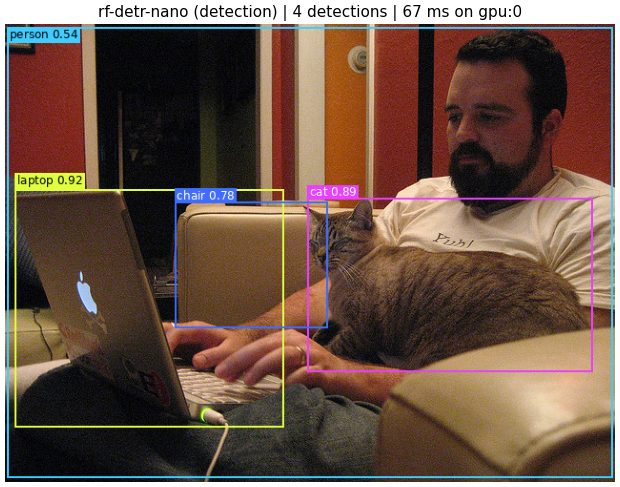

In [6]:
show(photo("cat"), res)

**What you see**

The photo with one colored box for each object. The label on each box is `class conf`, for
example `cat 0.89`. The title shows the model, the task, the number of results and the time.
Look at each box: does it fit the object? Is a class missing?

<details><summary><b>In detail</b></summary>

- `show` comes from `handson.py`. The SDK has its own drawing function too:
  `res.visualize(photo("cat")).save("out.jpg")` writes a picture file. See
  [Helpers](https://mtbui2010.github.io/visionserve/clients/python/#helpers).
- `rf-detr-nano` is the small version of RF-DETR. The big `rf-detr` finds more objects but is
  slower. Notebook 01 uses it. Compare them in [Models and performance](https://mtbui2010.github.io/visionserve/reference/models/).

</details>

## 7. The same request with `curl`

You do not need Python to use VisionServe. Any program that can send HTTP can use it. `curl` is
a command-line program for HTTP. In a notebook, a line that starts with `!` runs as a shell
command; `{...}` puts a Python value into the command.

The request is a **form** with two fields: `model` and `image` (`@` means "read this file").

In [7]:
!curl -s -F model=rf-detr-nano -F image=@{photo("cat")} {client.host}/api/predict

{"task":"detection","model":"rf-detr-nano","device":"gpu:0","detections":[{"bbox":[10.868959426879883,173.2867670059204,281.49389266967773,249.48060035705566],"class":"laptop","conf":0.9175987493193849},{"bbox":[317.83485412597656,182.31619119644165,298.5907745361328,182.54924297332764],"class":"cat","conf":0.8921594241442145},{"bbox":[178.4902048110962,186.02320432662964,159.7287654876709,132.48852252960205],"class":"chair","conf":0.7767849479382539},{"bbox":[2.729053497314453,3.552117347717285,635.1442337036133,471.8760395050049],"class":"person","conf":0.5410815911371543}],"duration_ms":29.693}


**What you see**

One long line of JSON. It has the same detections as in step 5 (the numbers have more digits).
`curl` prints the raw answer; the Python client turned the same text into objects for you.

<details><summary><b>In detail</b></summary>

- On Windows, `curl` is built in (Windows 10 and newer). In PowerShell write `curl.exe`.
- To add options, add more fields: `-F "prompt=cat. laptop."` or `-F box=200,150,250,250`. Every
  field is in [Plain HTTP](https://mtbui2010.github.io/visionserve/clients/http/) and the [HTTP API reference](https://mtbui2010.github.io/visionserve/reference/api/).
- If you get `{"error": ...}`, the HTTP status tells you why: 400 = bad request, 404 = unknown
  or not downloaded model, 503 = server busy (try again later).

</details>

## 8. Large photos: client resize

Phone photos are large (for example 4000 x 3000 pixels), but most models only use a small
image (here 384 x 384). So the Python client **makes a large photo smaller before it sends
it** (this is called *client resize*). The answer still uses the pixels of your original photo.

Below we make the cat photo 4 times larger and send it. `res.client_resize` tells us what the
client did. For the normal 640 x 480 photo it is `None`: the photo was sent as it is.

In [8]:
big = Image.open(photo("cat")).resize((2560, 1920))
res_big = client.predict("rf-detr-nano", big)

print("normal photo:", res.client_resize)
print("large photo: ", res_big.client_resize)
for d in res_big.detections[:2]:
    print(f"{d.cls:8s} bbox={[round(v) for v in d.bbox]}   (in the 2560 x 1920 photo)")

normal photo: None
large photo:  ClientResize(original_width=2560, original_height=1920, sent_width=1024, sent_height=768, jpeg_quality=90, reason='hint')
laptop   bbox=[44, 694, 1126, 997]   (in the 2560 x 1920 photo)
cat      bbox=[1273, 729, 1193, 730]   (in the 2560 x 1920 photo)


**What you see**

- For the large photo, `client_resize` shows the original size (2560 x 1920) and the size that
  was really sent (smaller), and that it was sent as JPEG.
- The boxes are still in the pixels of the **large** photo: about 4 times the numbers of step 4.

<details><summary><b>In detail</b></summary>

- Client resize is on by default since SDK 0.2.0. Turn it off with `Client(resize="off")` or
  `predict(..., resize="off")`. Notebook 02 shows the options.
- On the same computer (`127.0.0.1`) the client only shrinks a photo when this makes it at least
  2 times smaller, because sending is free there. See
  [Client-side resizing](https://mtbui2010.github.io/visionserve/clients/python/#client-side-resizing-on-by-default) and
  [the loopback rule](https://mtbui2010.github.io/visionserve/clients/python/#the-loopback-rule).

</details>

## Recap

- VisionServe is a **server** that runs vision **models** on your computer. Your code is the
  **client**. They talk over **HTTP**; the answer is **JSON**.
- `connect()` checks the server. `client.list_models()` shows the models and their state.
- `ensure_model()` (or `visionserve pull NAME`) downloads a model once.
- `client.predict(model, photo)` returns a `Result`. A detection has `cls`, `conf` and
  `bbox = [x, y, w, h]` in **your** photo's pixels.
- `show(photo, res)` draws the answer. `curl -F model=... -F image=@...` does the same request
  without Python.

## Next

- **[01 · Tour of tasks](01-tour-of-tasks.ipynb)**: detection, open-vocabulary detection,
  segmentation, depth, faces, text, classification and CLIP, one example each.
- Read more: [Getting started](https://mtbui2010.github.io/visionserve/getting-started/) and [Concepts](https://mtbui2010.github.io/visionserve/concepts/).